# Introduction to Listening Machines - Audio Signal Processing

# Testing Your Notebook Setup
## Run the following cell by selecting the cell and pressing Shift + Enter - the recording_filename should print!

In [10]:
import sounddevice, soundfile, librosa
print(sounddevice.__version__, soundfile.__version__, librosa.__version__)

0.5.5 0.13.1 0.11.0


In [3]:
recording_filename = 'recording.wav'

print(recording_filename)

recording.wav


# Recording Audio

In [11]:
# Recording audio with sounddevice and soundfile
# 
# https://python-soundfile.readthedocs.io/
# https://python-sounddevice.readthedocs.io

import sounddevice as sd
import soundfile as sf
import numpy as np
import time

# config
samplerate = 44100
duration = 10
channels = 1

print(f"Recording for {duration} seconds at {samplerate} Hz...")

# record audio from the microphone into a numpy array with sounddevice
recording = sd.rec(
    int(duration * samplerate),
    samplerate=samplerate,
    channels=channels,
    dtype='float32'
)
sd.wait()

print(f"Recording finished. Saving to {recording_filename}...")

# save the file with soundfile
sf.write(
    recording_filename,
    recording,
    samplerate,
    subtype='PCM_16'
    )

print(f"File '{recording_filename}' saved successfully.")

Recording for 10 seconds at 44100 Hz...
Recording finished. Saving to recording.wav...
File 'recording.wav' saved successfully.


# Playing Audio

In [12]:
# Recording audio with sounddevice and soundfile
# 
# https://python-soundfile.readthedocs.io/
# https://python-sounddevice.readthedocs.io

import sounddevice as sd
import soundfile as sf
import numpy as np

import sounddevice as sd
import soundfile as sf

# data is a numpy array!
data, samplerate = sf.read(
    recording_filename,
    dtype='float32'    
)

print(f"Playing '{recording_filename}'...")
sd.play(data, samplerate)

sd.wait()

print(f"Finished playing '{recording_filename}'.")

Playing 'recording.wav'...


KeyboardInterrupt: 

# Playing Audio with UI Element

In [ ]:
# Display the recording with iPython Display Audio
from IPython.display import Audio, display
Audio(recording_filename) # or Audio(data, rate=sample_rate) from the cell above

# Looking at Samples

Sample rate: 44100 Hz
Duration: : 10.00 seconds
Number of samples: 441000
Shape: (441000,)


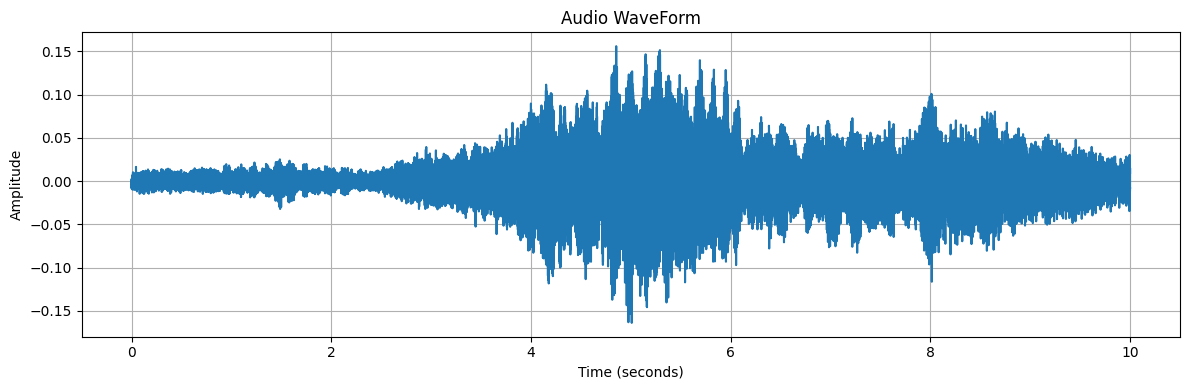

In [13]:
# Look at samples in a recording with NumPy and matplotlib
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

# load in our recording, data is the same as amplitude
data, sample_rate = sf.read(recording_filename)

# get some basic info
print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: : {len(data) / sample_rate:.2f} seconds")
print(f"Number of samples: {len(data)}")
print(f"Shape: {data.shape}") # (n_samples,) for mono (n samples, n_channels) for stereo

# create time axis in seconds
duration = len(data) / sample_rate
time = np.linspace(0, duration, len(data)) # not sure what linspace is? let's look at the documentation!

# plot the waveform
plt.figure(figsize=(12,4))
plt.plot(time, data) # x, y axis
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Audio WaveForm')
plt.grid(True)
plt.tight_layout()
plt.show()





# Manipulating Individual Samples

In [ ]:
# Looking at / accessing individual samples

# First 10 samples
print("First 10 samples: ", data[:10])

# Sample at 1 second
sample_at = 1.0 # seconds
sample_index = int(sample_at * samplerate)
print("Sample at 1 second: ", data[sample_index])

# min and max amplitude
print("Max amplitude: ", np.max(data))
print("Min amplitude: ", np.min(data))

First 10 samples:  [-0.00296021 -0.00500488 -0.00463867 -0.00393677 -0.00378418 -0.00442505
 -0.00509644 -0.00567627 -0.00579834 -0.00527954]
Sample at 1 second:  -0.0001220703125
Max amplitude:  0.051239013671875
Min amplitude:  -0.052703857421875


# Exercises for the Reader

In [ ]:
# Exercise: Silence seconds 2-3 in the recording and play it back

data_silenced = data.copy()
start_silenced_at = 2.0
end_silenced_at = 3.0
# silence second 2-3
start_silenced_index = int(start_silenced_at * samplerate)
end_silenced_index = int(end_silenced_at * samplerate)
data_silenced[start_silenced_index : end_silenced_index + 1] = 0

sd.play(data_silenced, samplerate)

sd.wait()

print(f"Finished playing '{recording_filename}'.")

Finished playing 'recording.wav'.


In [ ]:
# Exercise: Reverse the recording and play it back
data_reversed = data.copy()

for i in range(len(data)):
    data_reversed[i] = data[len(data) - 1 - i]

sd.play(data_reversed, samplerate)

sd.wait()

print(f"Finished playing '{recording_filename}'.")

Finished playing 'recording.wav'.


# FFT

[6.85797119 0.1184074  0.13687445 ... 0.10735261 0.13687445 0.1184074 ]


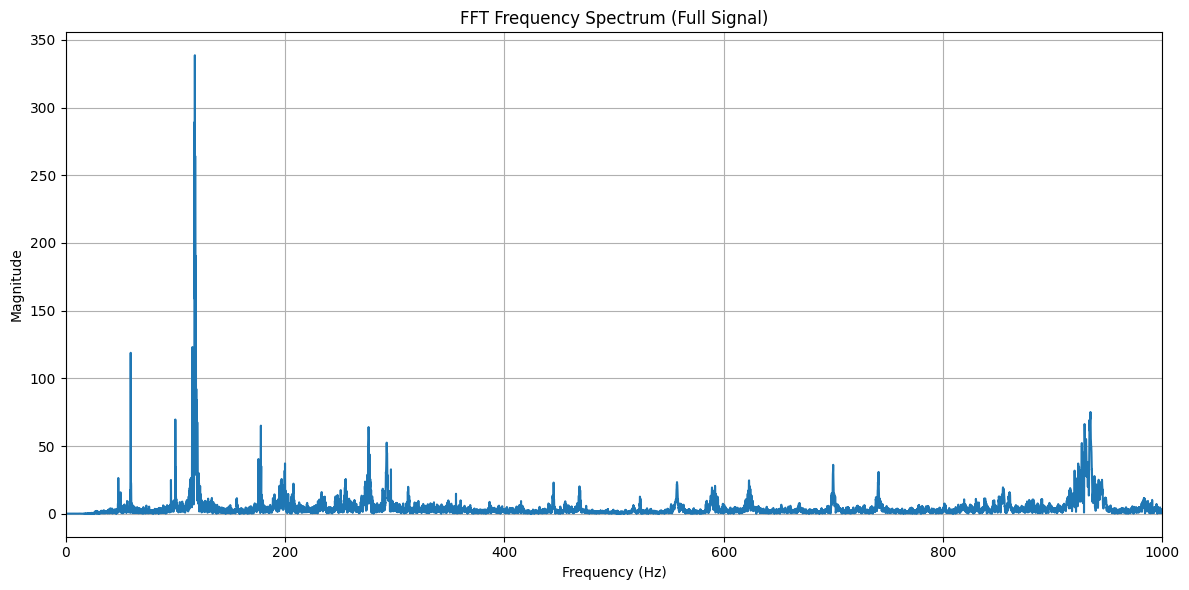

FFT computed on 441000 samples
Frequency resolution: 0.10 Hz per bin
Max frequency representable: 22050.0 Hz (Nyquist theorem)


In [ ]:
# Analyzing sound with FFT

# Origins of FFT
# Discrete Forier transform: https://en.wikipedia.org/wiki/Discrete_Fourier_transform
# Gauss: https://en.wikipedia.org/wiki/Carl_Friedrich_Gauss
# Fourier: https://en.wikipedia.org/wiki/Joseph_Fourier

# Cooley-Tukey FFT Algorithm 
# Original paper: https://www.ams.org/journals/mcom/1965-19-090/S0025-5718-1965-0178586-1/S0025-5718-1965-0178586-1.pdf
# Wikipedia: https://en.wikipedia.org/wiki/Cooley%E2%80%93Tukey_FFT_algorithm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplotlib
# matplotlib compatibility: some environments expect get_data_path on plt
plt.get_data_path = matplotlib.get_data_path
import soundfile as sf

# load in audio
data, sample_rate = sf.read(recording_filename)

# compute FFT using numpy
# FFT converts time-domain signal to frequency-domain
fft = np.fft.fft(data)
print(np.abs(fft))

# get magnitude spectrum (absolute values)
# this tells us how much energy is at each frequency
magnitude = np.abs(fft)

# create frequency axis
# np.fft.fftfreq gives us the frequency bins for the FFT output
# bins are frequency interval! we try to find which bin does our target freq that we're looking for fall into
freq_bins = np.fft.fftfreq(len(data), 1/sample_rate)

# only plot positive frequencies (FFT is symmetric)
# Nyquist theorem: we can only represent frequencies up to sample_rate / 2
positive_freq_idx = freq_bins >= 0
positive_freq = freq_bins[positive_freq_idx]
positive_magnitude = magnitude[positive_freq_idx]

# plot FFT spectrum
plt.figure(figsize=(12, 6))
plt.plot(positive_freq, positive_magnitude)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT Frequency Spectrum (Full Signal)')
plt.grid(True)
plt.xlim(0, 1000) # Focus on 0-5kHz - most audio content is here - comment this out / play with the values!
plt.tight_layout()
plt.show()

print(f"FFT computed on {len(data)} samples")
print(f"Frequency resolution: {sample_rate / len(data):.2f} Hz per bin")
print(f"Max frequency representable: {sample_rate / 2} Hz (Nyquist theorem)") # how would we affect this?





# STFT

In [ ]:
# Looking at Short-Time Fourier Transform (STFT) with librosa

import librosa
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplotlib
# matplotlib compatibility: some environments expect get_data_path on plt
plt.get_data_path = matplotlib.get_data_path

# load in recording with librosa
y, sr = librosa.load(recording_filename, sr=None)

# compute STFT
# STFT breaks down the signal into overlapping windows and computes FFT
# This gives us frequency content over time (unlike FFT which is frequency for the whole signal)

stft = librosa.stft(y)

# stft is a complex-valued matrix
# Shape: (n_frequencies, n_time_frames)
print(f"STFT shape: {stft.shape}")
print(f"Number of frequency bins: {stft.shape[0]}")
print(f"Number of time frames: {stft.shape[1]}")

# get magnitude/amplitude (absolute value) of STFT
magnitude = np.abs(stft)

# convert to decibles for better visualization
# this is the poewr spectral density in dB
S_db = librosa.power_to_db(magnitude**2, ref=np.max)

# plot STFT magnitude over time
# we can visualize it as a 2D plot: frequency vs time
plt.figure(figsize=(12,6))
plt.imshow(S_db, aspect='auto', origin='lower', cmap='viridis')
plt.xlabel('Time Frame')
plt.ylabel('Frequency Bin')
plt.title('STFT Magnitude (dB)')
plt.colorbar(label='dB')
plt.tight_layout()
plt.show()

# get actual frequency and time values
frequencies = librosa.fft_frequencies(sr=sr)
times = librosa.frames_to_time(np.arange(S_db.shape[1]), sr=sr )

print(f"Frequency range: {frequencies[0]:.1f} Hz to {frequencies[-1]:.1f} Hz")
print(f"Time range: {times[0]:.2f} s to {times[-1]:.2f} s")


OSError: Could not find/load shared object file

# Spectrograms

In [ ]:
# Looking at spectrogram

import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib as matplotlib
# matplotlib compatibility: some environments expect get_data_path on plt
plt.get_data_path = matplotlib.get_data_path

# load audio
y, sr = librosa.load(recording_filename, sr=None)

# compute STFT
D = librosa.stft(y)

# convert to power spectrogram (magnitude squared)
S = np.abs(D)**2

# Convert to decibels
S_db = librosa.power_to_db(S, ref=np.max)

# Visualize spectrogram using librosa's built-in display function
# This automatically handles frequency and time axes correctly
plt.figure(figsize=(12,6))
librosa.display.specshow(
    S_db,
    x_axis='time',
    y_axis='hz',
    sr=sr
    )
plt.colorbar(
    format='%+2.0f db', 
    label='Power (db)'
    )
plt.title('Spectrogram')
plt.tight_layout()
plt.show()

# above is a linar frequency scale
# we can use Mel scale which is more aligneed with our human ear perception of frequency

S_mel = librosa.feature.melspectrogram(y=y, sr=sr)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

plt.figure(figsize=(12,6))
librosa.display.specshow(
    S_mel_db,
    x_axis='time',
    y_axis='mel',
    sr=sr
    )
plt.colorbar(
    format='%+2.0f db', 
    label='Power (db)'
    )
plt.title('Mel Spectrogram')
plt.tight_layout()
plt.show()


# Real-time Audio Analysis from Microphone

In [ ]:
# Real time analysis from microphone
# Using sounddevice's callback to process audio as it comes in

import sounddevice as sd
import numpy as np

# config
SAMPLE_RATE = 44100
BLOCK_SIZE = 2048 # number of samples per block

def audio_callback(indata, frames, time, status):
    """This function is called for each audio block"""
    if status:
        print(f"Status: {status}")
    
    # indata is a numpy array of audio samples
    # calculate the volume using Root Mean Square (RMS)
    volume = np.sqrt(np.mean(indata**2))

    # simple volume metter with astrisks
    meter = '*' * int(volume * 200)
    print(f"Volume:  {meter}")

print("Listening to the microphone...stop this cell to stop")

try:
    with sd.InputStream(
        samplerate=SAMPLE_RATE,
        blocksize=BLOCK_SIZE,
        channels=1,
        callback=audio_callback
    ):
        sd.sleep(5000) # listen for 5 seconds

except KeyboardInterrupt:
    print("\nStopped")

Listening to the microphone...stop this cell to stop
Volume:  * 0.0066950200125575066
Volume:   0.0009022756712511182
Volume:   0.0006772485794499516
Volume:   0.0009202329092659056
Volume:   0.001635672291740775
Volume:   0.002037684665992856
Volume:   0.0016031373525038362
Volume:   0.00101854361128062
Volume:   0.0008656903519295156
Volume:   0.001104583847336471
Volume:   0.0010717357508838177
Volume:   0.0011786941904574633
Volume:   0.0008624856709502637
Volume:   0.000821207941044122
Volume:   0.0008360245265066624
Volume:   0.0012551078107208014
Volume:   0.002161883283406496
Volume:   0.0035798444878309965
Volume:   0.003614208195358515
Volume:   0.0027837143279612064
Volume:   0.002625386929139495
Volume:   0.002444725250825286
Volume:   0.0021746642887592316
Volume:   0.0024058790877461433
Volume:   0.002295754849910736
Volume:   0.002468799240887165
Volume:   0.0030336175113916397
Volume:   0.0027390357572585344
Volume:   0.0026266470085829496
Volume:   0.002872260054573416

# Fundamental Pitch

In [ ]:
# Fundamental pitch detection using FFT
# Find the strongest frequency in an audio recording

import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib as matplotlib
# matplotlib compatibility: some environments expect get_data_path on plt
plt.get_data_path = matplotlib.get_data_path

# load audio data
data, sample_rate = sf.read(recording_filename)

# if stereo, convert to mono
if len(data.shape) > 1:
    data = data[:, 0]

# take a short segment (e.g. 0.1 seconds) for analysis
segment_duration = 0.1 # in seconds
segment_samples = int(segment_duration * sample_rate)
segment = data[:segment_samples]

# compute FFT
fft = np.fft.fft(segment)
magnitude = np.abs(fft)

# get frequency bins
freq_bins = np.fft.fftfreq(len(segment), 1/sample_rate)

# only look at positive frequencies
positive_idx = freq_bins > 0
positive_freq = freq_bins[positive_idx]
positive_magnitude = magnitude[positive_idx]

# find the fundamental frequency (strongest frequency)
peak_idx = np.argmax(positive_magnitude)
fundamental_freq = positive_freq[peak_idx]

print(f"Fundamental frequency: {fundamental_freq:.1f} Hz")

# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freq, positive_magnitude)
plt.axvline(x=fundamental_freq, color='r', linestyle='--', label=f'Fundamental: {fundamental_freq:.1f} Hz')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Frequency Spectrum with Fundamental Pitch')
plt.xlim(0, 2000) # Focused within speech/music range
plt.legend()
plt.grid(True)
plt.show()


# Pitch Detection

In [ ]:
# Pitch detection from speech using librosa
# Track how pitch changes over time in a speech recording

# load audio
y, sr = librosa.load(recording_filename)

# use librosa's pyin for pitch detection
# pyin is good for speech and monophonic audio
# fmin and f max set the range for frequencies to look for

f0, voiced_flag, voiced_probs = librosa.pyin(
    y,
    fmin = 50, # min frequency (Hz) - low male voice
    fmax = 500, # maximum frequency (Hz) - high female voice
    sr = sr
)

# f0 contains the detected pitch for each time frame
# NaN (not a number) means no pitch deteted (silence or noise)

# get time values for each frame
times = librosa.times_like(f0, sr=sr)

# plot the pitch over time
plt.figure(figsize=(12, 4))
plt.plot(times, f0, label='Detected Pitch')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency (Hz)')
plt.title('Pitch (F0) OVer Time in Speech')
plt.grid(True)
plt.legend()
plt.show()

# print some states
valid_pitches = f0[~np.isnan(f0)] # remove NaN values
if len(valid_pitches) > 0:
    print(f"Average pitch: {np.mean(valid_pitches):.1f} Hz")
    print(f"Pitch range: {np.min(valid_pitches):.1f} - {np.max(valid_pitches):.1f} Hz")
else:
    print("No pitch detected in recording")


# Trigger an Action with Pitch

In [ ]:
# Detects a specific pitch from microphone and trigger an action
# Prints a message when we detect a pitch near 500hz

import sounddevice as sd
import numpy as np

# config
SAMPLE_RATE = 44100
BLOCK_SIZE = 4096
TARGET_FREQ = 500 # frequency to detect
TOLERANCE = 50
MIN_VOLUME = 0.01

def find_fundamental(audio_data, sample_rate):
    """Find the fundamental frequency in audio data using FFT"""

    # Compute FFT
    fft = np.fft.fft(audio_data)
    magnitude = np.abs(fft)

    # get frequency bins
    freq_bins = np.fft.fftfreq(len(audio_data), 1/sample_rate)

    # only look at the positive frequencies betweeen 50-2000 Hz
    valid_idx = (freq_bins > 50) & (freq_bins < 2000)

    if not np.any(valid_idx):
        return 0

    valid_freq = freq_bins[valid_idx]
    valid_magnitude = magnitude[valid_idx]

    # find peak frequency
    peak_idx = np.argmax(valid_magnitude)
    return valid_freq[peak_idx]


def audio_callback(indata, frames, time, status):
    """Called for each audio block"""
    if status:
        print(f'Status: {status}')

    # flatten to 1D array
    audio = indata[:, 0]

    # check if there is enough volume
    volume = np.sqrt(np.mean(audio**2))
    if volume < MIN_VOLUME:
        return

    # find the fundamental frequency
    freq = find_fundamental(audio, SAMPLE_RATE)

    # check if its close to our target
    if abs(freq - TARGET_FREQ) < TOLERANCE:
        print(f"Detected {freq:.0f} Hz! (Target: {TARGET_FREQ} Hz)")

# Start listening
print(f'Listening for ~{TARGET_FREQ} Hz...press Ctrl+C to stop')
print(f'Try whistling or playing a tone :)')

try:
    with sd.InputStream(
        samplerate=SAMPLE_RATE,
        blocksize=BLOCK_SIZE,
        channels=1,
        callback=audio_callback
    ):
        sd.sleep(30000) # listen for 30 seconds
except KeyboardInterrupt:
    print("\nStopped")

Listening for ~500 Hz...press Ctrl+C to stop
Try whistling or playing a tone :)
Detected 517 Hz! (Target: 500 Hz)
Detected 484 Hz! (Target: 500 Hz)
Detected 506 Hz! (Target: 500 Hz)
Detected 528 Hz! (Target: 500 Hz)


# Demo - Radio Rex example with Arduino

In [ ]:
# Pitch Detection → Arduino LED
# Turns LED on when target frequency is detected, off when it stops

import sounddevice as sd
import numpy as np
import serial
import time
import threading

# === CONFIGURATION ===
SAMPLE_RATE = 44100
BLOCK_SIZE = 4096
TARGET_FREQ = 100      # Frequency to detect (Hz)
TOLERANCE = 50         # How close to target (Hz)
MIN_VOLUME = 0.01      # Minimum volume to trigger
FRAMES_TO_TRIGGER = 3  # Frames needed to change state (smoothing)
LISTENING_DURATION = 60000 # Listen for 60 seconds

SERIAL_PORT = '/dev/tty.usbmodem14101' # find your serial port with this command: ls /dev/tty* | grep usb.
BAUD_RATE = 9600

# === SETUP ===
arduino = serial.Serial(SERIAL_PORT, BAUD_RATE)
time.sleep(2)  # Wait for Arduino to reset

state = {'led_on': False, 'on_count': 0, 'off_count': 0}
lock = threading.Lock()

def find_fundamental(audio_data, sample_rate):
    """Find the strongest frequency in audio using FFT"""
    fft = np.fft.fft(audio_data)
    magnitude = np.abs(fft)
    freq_bins = np.fft.fftfreq(len(audio_data), 1/sample_rate)
    
    # Only look at frequencies between 50-2000 Hz
    valid_idx = (freq_bins > 50) & (freq_bins < 2000)
    if not np.any(valid_idx):
        return 0
    
    valid_freq = freq_bins[valid_idx]
    valid_magnitude = magnitude[valid_idx]
    peak_idx = np.argmax(valid_magnitude)
    return valid_freq[peak_idx]

def audio_callback(indata, frames, time_info, status):
    """Called for each block of audio from the microphone"""
    audio = indata[:, 0]
    volume = np.sqrt(np.mean(audio**2))
    
    # Check if target frequency is detected
    detected = False
    if volume >= MIN_VOLUME:
        freq = find_fundamental(audio, SAMPLE_RATE)
        if abs(freq - TARGET_FREQ) < TOLERANCE:
            detected = True
    
    # Update state with thread safety
    with lock:
        if detected:
            state['on_count'] += 1
            state['off_count'] = 0
        else:
            state['off_count'] += 1
            state['on_count'] = 0
        
        # Turn LED on after consistent detection
        if not state['led_on'] and state['on_count'] >= FRAMES_TO_TRIGGER:
            state['led_on'] = True
            arduino.write(b'1')
            print("🎵 LED ON")
        
        # Turn LED off after consistent silence
        elif state['led_on'] and state['off_count'] >= FRAMES_TO_TRIGGER:
            state['led_on'] = False
            arduino.write(b'0')
            print("   LED OFF")

# === MAIN ===
print(f"Connected to Arduino on {SERIAL_PORT}")
print(f"Listening for ~{TARGET_FREQ} Hz... Press Ctrl+C to stop")
print()

try:
    with sd.InputStream(
        samplerate=SAMPLE_RATE,
        blocksize=BLOCK_SIZE,
        channels=1,
        callback=audio_callback
    ):
        sd.sleep(LISTENING_DURATION)
except KeyboardInterrupt:
    print("\nStopped")
finally:
    arduino.write(b'0')  # Turn off LED
    arduino.close()

Connected to Arduino on /dev/tty.usbmodem14101
Listening for ~100 Hz... Press Ctrl+C to stop

🎵 LED ON
   LED OFF

Stopped


In [ ]:
# Test Arduino connection (uses built-in LED command format '1'/'0')
import serial
import time

SERIAL_PORT = '/dev/cu.usbmodem14401'
BAUD_RATE = 9600

# The Arduino sketch listens for the single characters '1' and '0'
# so send those bytes directly (no pin prefix).

arduino = serial.Serial(SERIAL_PORT, BAUD_RATE)
time.sleep(2)  # Wait for Arduino to reset after connection

print('Connected! Sending test blinks...')

# Send 5 blinks
for i in range(5):
    print(f"Blink {i+1}")
    arduino.write(b'1')
    time.sleep(0.5)
    arduino.write(b'0')
    time.sleep(0.5)

arduino.close()
print("Done!")

Connected! Sending test blinks...
Blink 1
Blink 2
Blink 3


KeyboardInterrupt: 

# Homework

In [ ]:
# Exercise: Make something activate with pitch (simple)
# Consider sending signal to a p5 sketch over OSC for example


In [ ]:
## with 

## Amplitude / Magnitude Radio Rex

Connected to Arduino on /dev/tty.usbmodem14201
Listening for ~0.01 Hz... Press Ctrl+C to stop

Playing 'recording.wav'...
Volume: 0.003 | Increasing count: 0 | is_gershwin: False
Volume: 0.002 | Increasing count: 0 | is_gershwin: False
Volume: 0.002 | Increasing count: 0 | is_gershwin: False
Volume: 0.003 | Increasing count: 0 | is_gershwin: False
Volume: 0.002 | Increasing count: 0 | is_gershwin: False
Volume: 0.002 | Increasing count: 0 | is_gershwin: False
Volume: 0.003 | Increasing count: 0 | is_gershwin: False
Volume: 0.003 | Increasing count: 0 | is_gershwin: False
Volume: 0.002 | Increasing count: 0 | is_gershwin: False
Volume: 0.002 | Increasing count: 0 | is_gershwin: False
Volume: 0.003 | Increasing count: 0 | is_gershwin: False
Volume: 0.003 | Increasing count: 0 | is_gershwin: False
Volume: 0.003 | Increasing count: 0 | is_gershwin: False
Volume: 0.003 | Increasing count: 0 | is_gershwin: False
Volume: 0.003 | Increasing count: 0 | is_gershwin: False
Volume: 0.003 | Increas

ValueError: x and y must have same first dimension, but have shapes (1,) and (441000,)

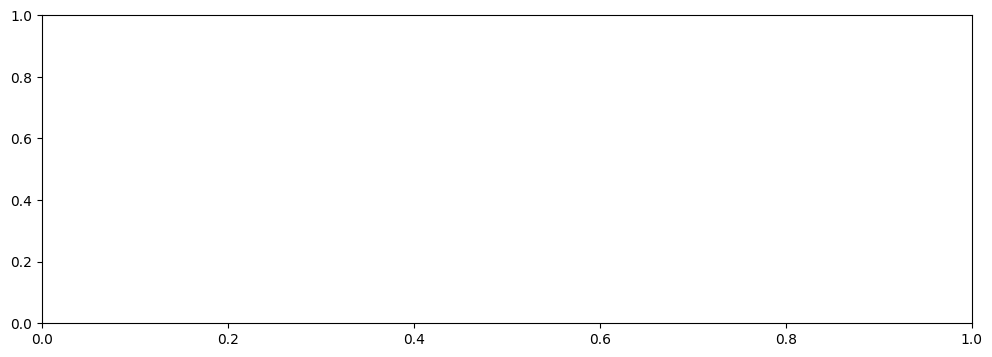

In [ ]:
# Exercise: Make something activate with speech and have it activate something physical in the world (harder!) 
# Hint: Analyze a speech recording and determine a fundamental frequency in that speech utterance
# Take a look into formants: https://en.wikipedia.org/wiki/Formant
# For example, with Radio Rex, it was "concluded that Rex was sensitive to vowels with resonances in the 500 Hz range"
# Try to make your project respond to something like "Yes", "No" or some other "command"
import sounddevice as sd
import soundfile as sf
import numpy as np
import serial
import time
import threading

# === CONFIGURATION ===
recording_filename = 'recording.wav' # pre-recorded audio file to analyze
SAMPLE_RATE = 44100
BLOCK_SIZE = 4096
TARGET_START_VOL = 0.01
TARGET_END_VOL = 0.04
TOLERANCE = 50         # How close to target (Hz)
FRAMES_TO_TRIGGER = 3  # Frames needed to change state (smoothing)
LISTENING_DURATION = 60000 # Listen for 60 seconds

SERIAL_PORT = '/dev/tty.usbmodem14201' # find your serial port with this command: ls /dev/tty* | grep usb.
BAUD_RATE = 9600

# === SETUP ===
arduino = serial.Serial(SERIAL_PORT, BAUD_RATE)
time.sleep(2)  # Wait for Arduino to reset
state_of_mag = { 'last': TARGET_START_VOL, 'count_mag_increasing': 0 }
is_gershwin = False


state = {'led_on': False, 'on_count': 0, 'off_count': 0}
lock = threading.Lock()

freqs = []
def audio_callback(data, frames, time_info, status):
    audio = data[:, 0]
    volume = np.sqrt(np.mean(audio**2)) # todo: can change this to  FFT magnitude later
    
    if volume >= TARGET_START_VOL:
        if (volume is not None):
            if volume > TARGET_END_VOL:
                state_of_mag['count_mag_increasing'] = 0
            elif volume > state_of_mag['last']:
                state_of_mag['count_mag_increasing'] += 1
                state_of_mag['last'] = volume
            else:
                state_of_mag['last'] = TARGET_START_VOL # reset
                state_of_mag['count_mag_increasing'] = 0 

    is_gershwin = state_of_mag['count_mag_increasing'] >= 3 
    print(f"Volume: {volume:.3f} | Increasing count: {state_of_mag['count_mag_increasing']} | is_gershwin: {is_gershwin}")


    # Update state with thread safety
    with lock:
        if is_gershwin:
            print("🤸🏼 Gershwin detected!")
            state['led_on'] = True
            arduino.write(b'1')
        else:
            state['led_on'] = False
            arduino.write(b'0')
        
# === MAIN ===
print(f"Connected to Arduino on {SERIAL_PORT}")

data, samplerate = sf.read(
    recording_filename,
    dtype='float32'    
)
print(f"Playing '{recording_filename}'...")
sd.play(data, samplerate)
try:
    with sd.InputStream(
        samplerate=SAMPLE_RATE,
        blocksize=BLOCK_SIZE,
        channels=1,
        callback=audio_callback
    ):
        sd.sleep(LISTENING_DURATION)
except KeyboardInterrupt:
    print("\nStopped")
finally:
    arduino.write(b'0')  # Turn off LED
    arduino.close()

print(f"Finished playing '{recording_filename}'.")


In [ ]:
import soundfile as sf
import matplotlib.pyplot as plt

data, samplerate = sf.read(
    recording_filename,
    dtype='float32'    
)
print(f"Playing '{recording_filename}'...")
sd.play(data, samplerate)

# === AMPLITUDE PLOT to HELP ANALYZE ===
plt.figure(figsize=(12, 4))
plt.plot(samplerate, data, label='Magnitude/Amplitude') # TODO: later change data to data from the input stream 
plt.xlabel('Time (seconds)')
plt.ylabel('Magnitude')
plt.title('Magnitude/Amplitude Over Time in Speech')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Extra Credit

# Playing with playback speed, volume, other effects
# Reconstructing sound with iFFT
# Look at auto correleation
# Look at other kinds of pitch detection (e.g. auto-correlation)
# Look at other kinds of time/frequency/amplitude functions

## Frequency Radio Rex

In [5]:
# Exercise: Make something activate with speech and have it activate something physical in the world (harder!) 
# Hint: Analyze a speech recording and determine a fundamental frequency in that speech utterance
# Take a look into formants: https://en.wikipedia.org/wiki/Formant
# For example, with Radio Rex, it was "concluded that Rex was sensitive to vowels with resonances in the 500 Hz range"
# Try to make your project respond to something like "Yes", "No" or some other "command"
import sounddevice as sd
import soundfile as sf
import numpy as np
import serial
import time
import threading
import matplotlib.pyplot as plt

# === CONFIGURATION ===
recording_filename = 'recording.wav' # pre-recorded audio file to analyze
SAMPLE_RATE = 44100
BLOCK_SIZE = 4096
TARGET_START_VOL = 0.01 # prevent any noise sound coming in
TARGET_START_FREQ = 400
TARGET_END_FREQ = 1000
TOLERANCE = 50         # How close to target (Hz)
FRAMES_TO_TRIGGER = 3  # Frames needed to change state (smoothing)
LISTENING_DURATION = 60000 # Listen for 60 seconds

SERIAL_PORT = '/dev/tty.usbmodem14101' # find your serial port with this command: ls /dev/tty* | grep usb.
BAUD_RATE = 9600

# === SETUP ===
arduino = serial.Serial(SERIAL_PORT, BAUD_RATE)
time.sleep(2)  # Wait for Arduino to reset
state_of_freq = { 'last_freq': TARGET_START_FREQ, 'count_freq_increasing': 0, 'has_reached_target': False }
is_gershwin = False


state = {'led_on': False, 'on_count': 0, 'off_count': 0}
lock = threading.Lock()

freqs = []
def audio_callback(data, frames, time_info, status):
    audio = data[:, 0]
    volume = np.sqrt(np.mean(audio**2)) # todo: can change this to  FFT magnitude later
    
    # get the frequency
    fft = np.fft.fft(audio)
    magnitude = np.abs(fft) # optional

    freq_bins = np.fft.fftfreq(len(audio), 1/SAMPLE_RATE)
    
    # only look at positive frequencies
    positive_idx = freq_bins > 0
    positive_freq = freq_bins[positive_idx]
    positive_magnitude = magnitude[positive_idx]

    # find the fundamental frequency (strongest frequency)
    peak_idx = np.argmax(positive_magnitude)
    fundamental_freq = positive_freq[peak_idx]

    if fundamental_freq >= TARGET_START_FREQ and volume >= TARGET_START_VOL:
        if (fundamental_freq is not None):
            if fundamental_freq > state_of_freq['last_freq']:
                state_of_freq['count_freq_increasing'] += 1
                state_of_freq['last_freq'] = fundamental_freq
                if (fundamental_freq > TARGET_END_FREQ):
                    state_of_freq['has_reached_target'] = True
                else:
                    state_of_freq['has_reached_target'] = False
            else:
                state_of_freq['last_freq'] = TARGET_START_FREQ # reset
                state_of_freq['has_reached_target'] = False # reset
                state_of_freq['count_freq_increasing'] = 0

    is_gershwin = state_of_freq['has_reached_target']
    is_light_up = state_of_freq['count_freq_increasing'] >= 3 
    print(f"Freq: {fundamental_freq:.3f} | Increasing count: {state_of_freq['count_freq_increasing']} | is_gershwin: {is_gershwin}")


    # Update state with thread safety
    with lock:
        if is_gershwin:
            state['led_on'] = True
            arduino.write(b'1')
        else:
            state['led_on'] = False
            arduino.write(b'0')
        
# === MAIN ===
print(f"Connected to Arduino on {SERIAL_PORT}")
print(f"Listening for ~{TARGET_START_FREQ} Hz... Press Ctrl+C to stop")
print()

data, samplerate = sf.read(
    recording_filename,
    dtype='float32'    
)
print(f"Playing '{recording_filename}'...")
sd.play(data, samplerate)
try:
    with sd.InputStream(
        samplerate=SAMPLE_RATE,
        blocksize=BLOCK_SIZE,
        channels=1,
        callback=audio_callback
    ):
        sd.sleep(LISTENING_DURATION)
except KeyboardInterrupt:
    print("\nStopped")
finally:
    arduino.write(b'0')  # Turn off LED
    arduino.close()

print(f"Finished playing '{recording_filename}'.")


Connected to Arduino on /dev/tty.usbmodem14101
Listening for ~400 Hz... Press Ctrl+C to stop

Playing 'recording.wav'...
Freq: 592.163 | Increasing count: 1 | is_gershwin: False
Freq: 592.163 | Increasing count: 0 | is_gershwin: False
Freq: 592.163 | Increasing count: 1 | is_gershwin: False
Freq: 172.266 | Increasing count: 1 | is_gershwin: False
Freq: 193.799 | Increasing count: 1 | is_gershwin: False
Freq: 592.163 | Increasing count: 0 | is_gershwin: False
Freq: 592.163 | Increasing count: 1 | is_gershwin: False
Freq: 193.799 | Increasing count: 1 | is_gershwin: False
Freq: 990.527 | Increasing count: 2 | is_gershwin: False
Freq: 979.761 | Increasing count: 0 | is_gershwin: False
Freq: 990.527 | Increasing count: 1 | is_gershwin: False
Freq: 990.527 | Increasing count: 0 | is_gershwin: False
Freq: 979.761 | Increasing count: 1 | is_gershwin: False
Freq: 979.761 | Increasing count: 0 | is_gershwin: False
Freq: 990.527 | Increasing count: 1 | is_gershwin: False
Freq: 592.163 | Increasi

/Users/ekw2458/Documents/GitHub/listening_machines/.venv/lib/python3.12/site-packages/numba/cpython/hashing.py:477: UserWarning: FNV hashing is not implemented in Numba. See PEP 456 https://www.python.org/dev/peps/pep-0456/ for rationale over not using FNV. Numba will continue to work, but hashes for built in types will be computed using siphash24. This will permit e.g. dictionaries to continue to behave as expected, however anything relying on the value of the hash opposed to hash as a derived property is likely to not work as expected.
  warnings.warn(msg)


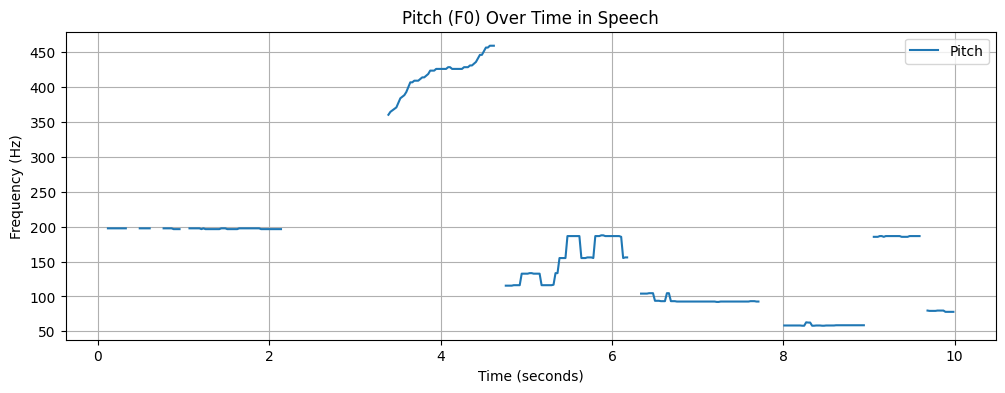

In [2]:
import librosa
import matplotlib.pyplot as plt

# === FREQUENCY PLOT to HELP ANALYZE ===
# plot magnitude/amplitude over time
duration = len(data) / SAMPLE_RATE
time = np.linspace(0, duration, len(data))

y, sr = librosa.load(recording_filename)

# use librosa's pyin for pitch detection
# pyin is good for speech and monophonic audio
# fmin and f max set the range for frequencies to look for

f0, voiced_flag, voiced_probs = librosa.pyin(
    y,
    fmin = 50, # min frequency (Hz) - low male voice
    fmax = 500, # maximum frequency (Hz) - high female voice
    sr = sr
)

# f0 contains the detected pitch for each time frame
# NaN (not a number) means no pitch deteted (silence or noise)

# get time values for each frame
times = librosa.times_like(f0, sr=sr)


# plot the pitch over time (FFT)
plt.figure(figsize=(12, 4))
plt.plot(times, f0, label='Pitch')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency (Hz)')
plt.title('Pitch (F0) Over Time in Speech')
plt.grid(True)
plt.legend()
plt.show()